In [220]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import interpolate
from scipy.integrate import simpson

# Objetivo:

Replicar de forma efectiva la atenuación generada por la tierra que se muestra en el paper mcp from the heavens. Como marcadores de que está todo bien vamos a usar como prueba los gráficos:

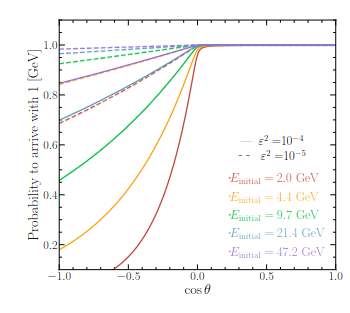


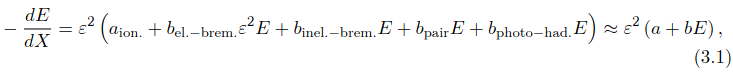

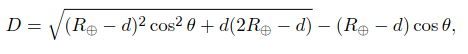

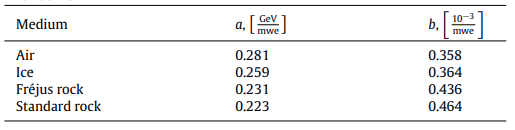

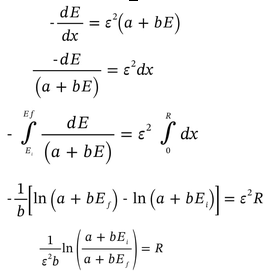

$$R = \frac{1}{\varepsilon^2 b}ln(\frac{1+\frac{b}{a}E_i}{1+\frac{b}{a}E_f})$$

In [221]:
def D_overburden(d,theta):
    '''
    Calculates the overburden distance D for a given depth d and zenith angle theta.
    d: depth in meters (of the experiment)
    theta: zenith angle in radians
    '''
    R_t = 6.378e6 # [m] Radio de la tierra
    D = np.sqrt((R_t-d)**2*((np.cos(theta))**2)+d*(2*R_t-d))-(R_t-d)*np.cos(theta)
    return D # resultado en METROS

In [222]:
# chequeo, en theta = 0, D = d, en theta = pi/2, D = sqrt(2*R_t*d)

D_overburden(2000, 0), D_overburden(2000, -np.pi),2*6.378e6-2000

(np.float64(2000.0), np.float64(12754000.0), 12754000.0)

In [246]:
# Función R
def R_average(eps, Ei, Ef, a=None, b=None):
    '''
    Calculates the average distance R that a mCP travels in the earth 
        eps: mCP charge fraction (e.g., 1e-3 for a mCP with charge 0.001e)
        Ei: initial energy of the mCP in the surface(in GeV)
        Ef: final energy of the mCP in the surface(in GeV)
        returns: R in meters using the formula R = (1/eps^2)*(1/b)*log((1+(a/b)*Ei)/(1+(a/b)*Ef))*(1/2.65)

    b is in 1/mwe units, so we may need to convert it to 1/m since D is 
    in meters. The paper says that this value was calculated for a "standard
    rock shielding so we consider 1 mwe = (1/2.65) m of rock "
    '''

    if a is None:
        a = 0.223 # [GeV/mwe]
    if b is None:
        b = 4.64e-4 # [1/mwe]

    R = ((1/(eps**2))*(1/b))*np.log((1+(b/a)*Ei)/(1+(b/a)*Ef)) # [mwe]
    R = R*60 # [m]
    return R 


Dado que R está en mwe y queremos que esté en metros tenemos que hacer la conversión de esa distancia. En teoría y con los dedos podría dividir por la densidad de la roca estándar, pero no sé si alcanza con eso.

$$
1 m.w.e = 100 g/cm²
$$

In [247]:
def P_arrival(eps, Ei, Ef, d, theta):
    '''
    Calculates the probability of arrival of a mCP at the detector given its charge fraction, initial and final energy, depth of the experiment, and zenith angle.
    eps: mCP charge fraction
    Ei: initial energy of the mCP in GeV
    Ef: final energy of the mCP in GeV
    d: depth of the experiment in meters
    theta: zenith angle in radians
    returns: probability of arrival at the detector
    '''
    D = D_overburden(d, theta) # Calculate overburden distance D
    R = R_average(eps, Ei, Ef) # Calculate average distance R that the mCP travels in the earth
    P = np.exp(-D/R) # Probability of arrival using the formula P = exp(-D/R)
    return P

In [248]:
# Probamos

Ef = 1 # GeV
Ei = np.array([2,4.4,9.7,21.4,47.2])# GeV
eps2 = np.array([1e-6,1e-4])
theta = np.linspace(-np.pi, 0, 1000) 
P_E0 = np.zeros((len(Ei), len(theta)))
P_E1 = np.zeros((len(Ei), len(theta)))
d = 1500 # Depth of the experiment in meters
for i in range(len(Ei)):
    P_0 = P_arrival(np.sqrt(eps2[0]), Ei[i], Ef, d, theta)
    P_1 = P_arrival(np.sqrt(eps2[1]), Ei[i], Ef, d, theta)
    P_E0[i,:] = P_0
    P_E1[i,:] = P_1

In [249]:
np.cos(-np.pi)

np.float64(-1.0)

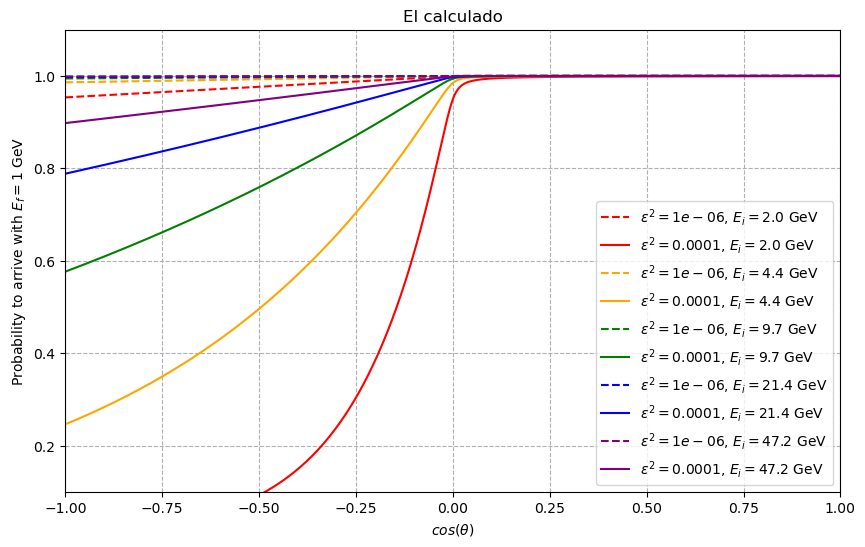

In [250]:
plt.close('all')
colors = ['red', 'orange', 'green', 'blue', 'purple']
plt.figure(figsize=(10, 6))
for i in range(len(Ei)):
    plt.plot(np.cos(theta),P_E0[i,:], label=rf'$\epsilon^2 = {eps2[0]}$, $E_i =${Ei[i]} GeV',color = colors[i],linestyle='--')
    plt.plot(np.cos(theta), P_E1[i,:], label=rf'$\epsilon^2 = {eps2[1]}$, $E_i =${Ei[i]} GeV', color = colors[i])
    plt.xlabel(f'$cos(\\theta)$')
    plt.ylabel('Probability to arrive with $E_f = 1$ GeV')
    plt.legend()

plt.xlim(-1, 1)
plt.ylim(0.1, 1.1)

plt.title('El calculado')
plt.grid(linestyle='--')

In [228]:
df_4_2_0=pd.read_csv('/home/lurishi/Escritorio/Doctorado/Proba_atenuacion/Ei_2_0_1e-4.csv',sep=';')
df_4_4_4 = pd.read_csv('/home/lurishi/Escritorio/Doctorado/Proba_atenuacion/Ei_4_4_1e-4.csv',sep=';')
df_4_9_7 = pd.read_csv('/home/lurishi/Escritorio/Doctorado/Proba_atenuacion/Ei_9_7_1e-4.csv',sep=';')
df_4_21_4 = pd.read_csv('/home/lurishi/Escritorio/Doctorado/Proba_atenuacion/Ei_21_4_1e-4.csv',sep=';')
df_4_47_2 = pd.read_csv('/home/lurishi/Escritorio/Doctorado/Proba_atenuacion/Ei_47_2_1e-4.csv',sep=';')

In [229]:
cos = np.cos(theta)
prob1 = interpolate.interp1d(df_4_2_0[df_4_2_0.columns[0]], df_4_2_0[df_4_2_0.columns[1]], kind='linear', fill_value='extrapolate')
prob2 = interpolate.interp1d(df_4_4_4[df_4_4_4.columns[0]], df_4_4_4[df_4_4_4.columns[1]], kind='linear', fill_value='extrapolate')   
prob3 = interpolate.interp1d(df_4_9_7[df_4_9_7.columns[0]], df_4_9_7[df_4_9_7.columns[1]], kind='linear', fill_value='extrapolate')   
prob4 = interpolate.interp1d(df_4_21_4[df_4_21_4.columns[0]], df_4_21_4[df_4_21_4.columns[1]], kind='linear', fill_value='extrapolate')
prob5 = interpolate.interp1d(df_4_47_2[df_4_47_2.columns[0]], df_4_47_2[df_4_47_2.columns[1]], kind='linear', fill_value='extrapolate')


In [230]:
mask = cos <= 0
mask1 = np.logical_and(prob1(cos) >= 0.1 , cos <= 0)

[0.35536106 0.35745519 0.35952289 0.36156417 0.36357906 0.3655676
 0.36752982 0.36946576 0.37137545 0.37325894 0.37511627 0.3769475
 0.37875266 0.38053181 0.382285   0.38401229 0.38571373 0.38738939
 0.38903933 0.39066361 0.39265539 0.39464097 0.39659745 0.39852491
 0.40042343 0.4022931  0.40413399 0.4059462  0.40772981 0.40948492
 0.41121161 0.41290998 0.41458012 0.41622215 0.41783615 0.41942223
 0.42108011 0.42331374 0.42551317 0.42767853 0.42980996 0.43190757
 0.43397151 0.43600191 0.43799891 0.43996264 0.44189324 0.44379086
 0.44565565 0.44752977 0.44989449 0.45222129 0.45451032 0.45676176
 0.45897578 0.46115256 0.46329228 0.46539511 0.46746124 0.46949085
 0.47148413 0.47344127 0.47536245 0.47724786 0.47909769 0.48102378
 0.48360641 0.48614577 0.48864211 0.49109564 0.49350661 0.49587525
 0.49820181 0.50048652 0.50272963 0.50493137 0.507092   0.50921176
 0.51129089 0.51332966 0.5153283  0.51728708 0.51926411 0.52257857
 0.52583846 0.52904411 0.53219586 0.53529405 0.538339   0.541331

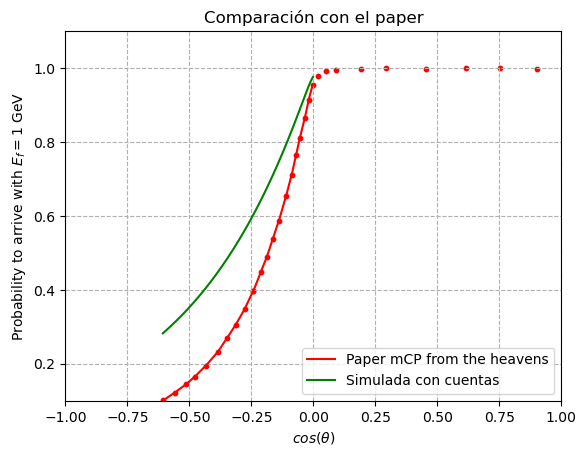

In [231]:
plt.plot(cos[mask1],prob1(cos)[mask1], label=rf'Paper mCP from the heavens',color = colors[0],linestyle='-')
plt.scatter(df_4_2_0[df_4_2_0.columns[0]], df_4_2_0[df_4_2_0.columns[1]], color = colors[0], s=10)
plt.plot(cos[mask1],P_E1[0,:][mask1], label=rf'Simulada con cuentas',color = colors[2],linestyle='-')

#plt.scatter(df_4_9_7[df_4_9_7.columns[0]], df_4_9_7[df_4_9_7.columns[1]], color = colors[2], s=10)
#plt.plot(cos,prob4(cos), label=rf'$\epsilon^2 = {eps2[1]}$, $E_i =${Ei[3]} GeV',color = colors[3],linestyle='-')
#plt.scatter(df_4_21_4[df_4_21_4.columns[0]], df_4_21_4[df_4_21_4.columns[1]], color = colors[3], s=10)
#plt.plot(cos,prob5(cos), label=rf'$\epsilon^2 = {eps2[1]}$, $E_i =${Ei[4]} GeV',color = colors[4],linestyle='-')
#plt.scatter(df_4_47_2[df_4_47_2.columns[0]], df_4_47_2[df_4_47_2.columns[1]], color = colors[4], s=10)
plt.xlim([-1, 1])
plt.ylim([0.1,1.1])
plt.grid(True, linestyle='--')
plt.title('Comparación con el paper')
plt.xlabel(f'$cos(\\theta)$')
plt.ylabel('Probability to arrive with $E_f = 1$ GeV')
print((prob1(cos)[mask1]/P_E1[0,:][mask1]))
plt.legend()

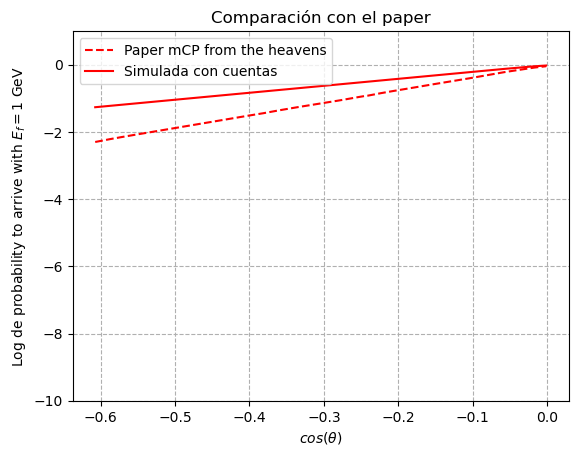

In [232]:
plt.plot(cos[mask1], np.log(prob1(cos)[mask1]), label=rf'Paper mCP from the heavens',color = colors[0],linestyle='--')
#plt.plot(cos[prob2(cos)>0.1], np.log(prob2(cos)[prob2(cos)>0.1]), label=rf'$\epsilon^2 = {eps2[1]}$, $E_i =${Ei[1]} GeV',color = colors[1],linestyle='--')
#plt.plot(cos[prob3(cos)>0.1], np.log(prob3(cos)[prob3(cos)>0.1]), label=rf'$\epsilon^2 = {eps2[1]}$, $E_i =${Ei[2]} GeV',color = colors[2],linestyle='--')
#plt.plot(cos[prob4(cos)>0.1], np.log(prob4(cos)[prob4(cos)>0.1]), label=rf'$\epsilon^2 = {eps2[1]}$, $E_i =${Ei[3]} GeV',color = colors[3],linestyle='--')
#plt.plot(cos[prob5(cos)>0.1], np.log(prob5(cos)[prob5(cos)>0.1]), label=rf'$\epsilon^2 = {eps2[1]}$, $E_i =${Ei[4]} GeV',color = colors[4],linestyle='--') 
    
plt.plot(np.cos(theta)[mask1], np.log(P_E1[0,:][mask1]), label=rf'Simulada con cuentas',color = colors[0])
#plt.plot(np.cos(theta)[prob2(cos)>0.1], np.log(P_E1[1,:][prob2(cos)>0.1]), label=rf'$\epsilon^2 = {eps2[1]}$, $E_i =${Ei[1]} GeV',color = colors[1])
#plt.plot(np.cos(theta)[prob3(cos)>0.1], np.log(P_E1[2,:][prob3(cos)>0.1]), label=rf'$\epsilon^2 = {eps2[1]}$, $E_i =${Ei[2]} GeV',color = colors[2])
#plt.plot(np.cos(theta)[prob4(cos)>0.1], np.log(P_E1[3,:][prob4(cos)>0.1]), label=rf'$\epsilon^2 = {eps2[1]}$, $E_i =${Ei[3]} GeV',color = colors[3])
#plt.plot(np.cos(theta)[prob5(cos)>0.1], np.log(P_E1[4,:][prob5(cos)>0.1]), label=rf'$\epsilon^2 = {eps2[1]}$, $E_i =${Ei[4]} GeV',color = colors[4])
plt.grid(True, linestyle='--')
plt.title('Comparación con el paper')
plt.xlabel(f'$cos(\\theta)$')
plt.ylabel('Log de probability to arrive with $E_f = 1$ GeV')
plt.ylim([-10,1])
plt.legend()
plt.show()

[3368723.76099138 3371102.44828258 3373329.4810712  3375405.01867181
 3377329.19879366 3379102.13818331 3380723.93323934 3382194.66060052
 3383514.37770888 3384683.12334883 3385700.9181636  3386567.76515011
 3387283.65013328 3387848.54222081 3388262.39423946 3388525.14315348
 3388636.71046631 3388597.00260613 3388405.91129612 3388063.31391011
 3389190.08663134 3390245.75288344 3391135.62530026 3391859.66573168
 3392417.81542525 3392809.9955513  3393036.10770543 3393096.03438962
 3392989.63947295 3392716.76863284 3392277.24977781 3391670.89345266
 3390897.49322675 3389956.82606628 3388848.65269132 3387572.71791817
 3386542.85223378 3387855.4546613  3388976.35526103 3389905.44628469
 3390642.59111672 3391187.62497401 3391540.35557207 3391700.56375962
 3391668.00412288 3391442.40556142 3391023.47183663 3390410.88209438
 3389604.291363   3388780.12863425 3389964.89199492 3390936.69383724
 3391695.24971276 3392240.24004549 3392571.3108786  3392688.07458156
 3392590.11051985 3392276.96568916

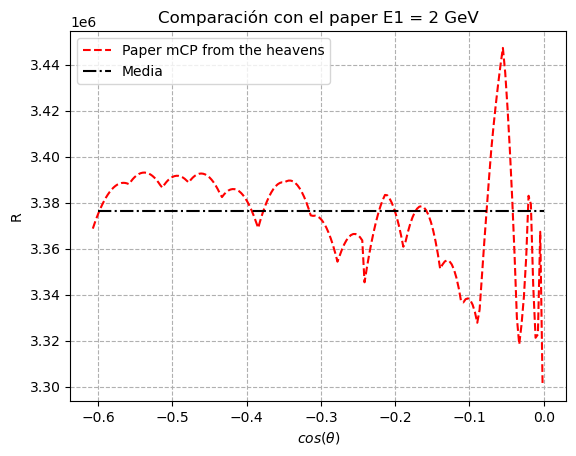

In [233]:
D = D_overburden(d, theta) # Calculate overburden distance D

plt.plot(cos[mask1], (np.log(prob1(cos)[mask1])/-D[mask1])**-1, label=rf'Paper mCP from the heavens',color = colors[0],linestyle='--')

#plt.plot(np.cos(theta)[mask1], (np.log(P_E1[0,:][mask1])/-D[mask1])**-1, label=rf'Simulada con cuentas',color = colors[0])
plt.hlines(y = np.mean((np.log(prob1(cos)[mask1])/-D[mask1])**-1), xmin=-0.6, xmax=0, color='k', linestyle='-.', label='Media')
plt.grid(True, linestyle='--')
plt.title('Comparación con el paper E1 = 2 GeV')
plt.xlabel(f'$cos(\\theta)$')
plt.ylabel('R')
print((np.log(prob1(cos)[mask1])/-D[mask1])**-1)
print((np.mean((np.log(prob1(cos)[mask1])/-D[mask1])**-1/(np.log(P_E1[0,:][mask1])/-D[mask1])**-1)))

plt.legend()
plt.show()

[7504083.93737535 7504084.50664096 7504086.21253871 7504089.04937141
 7504093.00764418 7504098.07406515 7504104.23154634 7504111.45920492
 7504119.7323646  7504129.02255741 7504139.29752568 7504150.52122427
 7504162.65382312 7504175.65171001 7504189.46749361 7504204.05000677
 7504219.34431007 7504235.29169566 7504251.82969131 7504268.89206474
 7504286.40882821 7504304.30624334 7504322.50682617 7504340.92935253
 7504359.48886358 7504378.09667167 7504396.66036633 7504415.08382064
 7504433.26719774 7504451.10695759 7504468.49586402 7504485.32299193
 7504501.47373478 7504516.82981226 7504531.26927827 7504544.66652897
 7504556.8923112  7504567.81373104 7504577.2942626  7504585.19375699
 7504591.36845154 7504595.67097921 7504597.95037818 7504598.05210168
 7504595.81802794 7504591.08647045 7504583.69218824 7504573.46639654
 7504560.23677745 7504543.82749087 7504524.05918564 7504500.74901072
 7504473.7106267  7504442.75421733 7504407.68650132 7504368.3107442
 7504324.42677041 7504275.83097551 

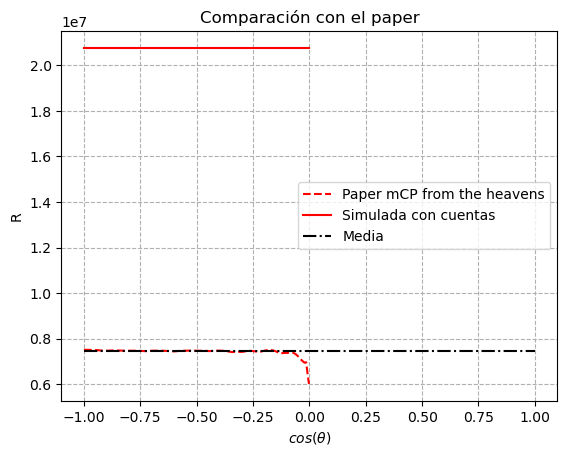

In [234]:
D = D_overburden(d, theta) # Calculate overburden distance D
plt.plot(cos[mask], (np.log(prob2(cos)[mask])/-D[mask])**-1, label=rf'Paper mCP from the heavens',color = colors[0],linestyle='--')

plt.plot(np.cos(theta)[mask], (np.log(P_E1[1,:][mask])/-D[mask])**-1, label=rf'Simulada con cuentas',color = colors[0])
plt.hlines(y = np.mean((np.log(prob2(cos)[mask])/-D[mask])**-1), xmin=-1.0, xmax=1, color='k', linestyle='-.', label='Media')
plt.grid(True, linestyle='--')
plt.title('Comparación con el paper')
plt.xlabel(f'$cos(\\theta)$')
plt.ylabel('R')
print((np.log(prob2(cos)[mask])/-D[mask])**-1)
print((np.mean((np.log(prob2(cos)[mask])/-D[mask])**-1/(np.log(P_E1[1,:][mask])/-D[mask])**-1)))
plt.legend()
plt.show()

[6.13768129e-08 6.13767841e-08 6.13766977e-08 6.13765536e-08
 6.13763521e-08 6.13760930e-08 6.13757765e-08 6.13754026e-08
 6.13749715e-08 6.13744832e-08 6.13739378e-08 6.13733355e-08
 6.13726765e-08 6.13719608e-08 6.13711887e-08 6.13703604e-08
 6.13694760e-08 6.13685358e-08 6.13675400e-08 6.13664889e-08
 6.13653827e-08 6.13642217e-08 6.13630062e-08 6.13617364e-08
 6.13604127e-08 6.13590355e-08 6.13576050e-08 6.13561217e-08
 6.13545858e-08 6.13529979e-08 6.13513582e-08 6.13496672e-08
 6.13479254e-08 6.13461331e-08 6.13442908e-08 6.13423990e-08
 6.13404582e-08 6.13384689e-08 6.13364316e-08 6.13343467e-08
 6.13322150e-08 6.13300368e-08 6.13278128e-08 6.13255436e-08
 6.13232297e-08 6.13208718e-08 6.13184704e-08 6.13160263e-08
 6.13135401e-08 6.13110124e-08 6.13084439e-08 6.13058353e-08
 6.13031874e-08 6.13005007e-08 6.12977762e-08 6.12950145e-08
 6.12922164e-08 6.12893827e-08 6.12865141e-08 6.12836115e-08
 6.12806757e-08 6.12777075e-08 6.12747078e-08 6.12716774e-08
 6.12686172e-08 6.126552

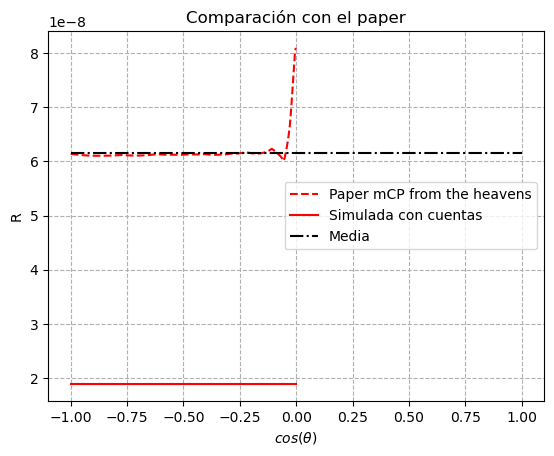

In [235]:
D = D_overburden(d, theta) # Calculate overburden distance D
plt.plot(cos[mask], np.log(prob3(cos)[mask])/-D[mask], label=rf'Paper mCP from the heavens',color = colors[0],linestyle='--')

plt.plot(np.cos(theta)[mask], np.log(P_E1[2,:][mask])/-D[mask], label=rf'Simulada con cuentas',color = colors[0])
plt.hlines(y = np.mean(np.log(prob3(cos)[mask])/-D[mask]), xmin=-1.0, xmax=1, color='k', linestyle='-.', label='Media')
plt.grid(True, linestyle='--')
plt.title('Comparación con el paper')
plt.xlabel(f'$cos(\\theta)$')
plt.ylabel('R')
print(np.log(prob3(cos)[mask])/-D[mask])
print((np.mean((np.log(prob3(cos)[mask])/-D[mask])**-1/(np.log(P_E1[2,:][mask])/-D[mask])**-1)))

plt.legend()
plt.show()

[ 2.80346473e-08  2.80346510e-08  2.80346622e-08  2.80346809e-08
  2.80347070e-08  2.80347407e-08  2.80347818e-08  2.80348305e-08
  2.80348867e-08  2.80349505e-08  2.80350218e-08  2.80351008e-08
  2.80351875e-08  2.80352818e-08  2.80353839e-08  2.80354937e-08
  2.80356113e-08  2.80357369e-08  2.80358703e-08  2.80360117e-08
  2.80361612e-08  2.80363188e-08  2.80364845e-08  2.80366584e-08
  2.80368407e-08  2.80370313e-08  2.80372303e-08  2.80374380e-08
  2.80376542e-08  2.80378791e-08  2.80381128e-08  2.80383554e-08
  2.80386070e-08  2.80388677e-08  2.80391376e-08  2.80394168e-08
  2.80397054e-08  2.80400035e-08  2.80403113e-08  2.80406288e-08
  2.80409562e-08  2.80412936e-08  2.80416411e-08  2.80419989e-08
  2.80423671e-08  2.80427459e-08  2.80431354e-08  2.80435357e-08
  2.80439470e-08  2.80443694e-08  2.80448032e-08  2.80452484e-08
  2.80457052e-08  2.80461738e-08  2.80466544e-08  2.80471472e-08
  2.80476522e-08  2.80481698e-08  2.80487000e-08  2.80492431e-08
  2.80497993e-08  2.80503

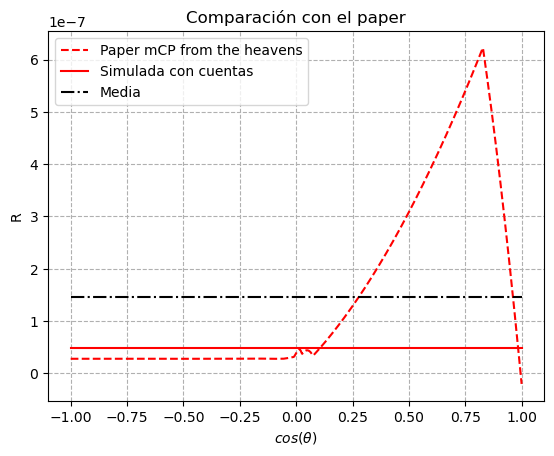

In [236]:
D = D_overburden(d, theta) # Calculate overburden distance D
plt.plot(cos, np.log(prob4(cos))/-D, label=rf'Paper mCP from the heavens',color = colors[0],linestyle='--')

plt.plot(np.cos(theta), np.log(P_E1[1,:])/-D, label=rf'Simulada con cuentas',color = colors[0])
plt.hlines(y = np.mean(np.log(prob4(cos))/-D), xmin=-1.0, xmax=1, color='k', linestyle='-.', label='Media')
plt.grid(True, linestyle='--')
plt.title('Comparación con el paper')
plt.xlabel(f'$cos(\\theta)$')
plt.ylabel('R')
print(np.log(prob4(cos))/-D)
print((np.mean((np.log(prob4(cos)[cos<0])/-D[cos<0])**-1/(np.log(P_E1[3,:][cos<0])/-D[cos<0])**-1)))

plt.legend()
plt.show()

[ 1.30624924e-08  1.30624939e-08  1.30624986e-08  1.30625064e-08
  1.30625174e-08  1.30625314e-08  1.30625486e-08  1.30625689e-08
  1.30625924e-08  1.30626190e-08  1.30626487e-08  1.30626816e-08
  1.30627177e-08  1.30627569e-08  1.30627994e-08  1.30628450e-08
  1.30628938e-08  1.30629459e-08  1.30630012e-08  1.30630597e-08
  1.30631215e-08  1.30631866e-08  1.30632549e-08  1.30633266e-08
  1.30634015e-08  1.30634798e-08  1.30635615e-08  1.30636466e-08
  1.30637350e-08  1.30638269e-08  1.30639222e-08  1.30640210e-08
  1.30641233e-08  1.30642290e-08  1.30643384e-08  1.30644512e-08
  1.30645677e-08  1.30646878e-08  1.30648115e-08  1.30649390e-08
  1.30650701e-08  1.30652049e-08  1.30653436e-08  1.30654860e-08
  1.30656322e-08  1.30657824e-08  1.30659364e-08  1.30660944e-08
  1.30662563e-08  1.30664223e-08  1.30665923e-08  1.30667664e-08
  1.30669446e-08  1.30671270e-08  1.30673136e-08  1.30675045e-08
  1.30676996e-08  1.30678991e-08  1.30681030e-08  1.30683113e-08
  1.30685242e-08  1.30687

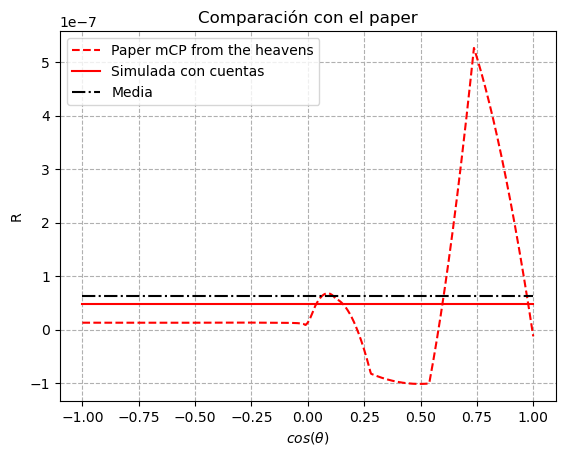

In [237]:
D = D_overburden(d, theta) # Calculate overburden distance D
plt.plot(cos, np.log(prob5(cos))/-D, label=rf'Paper mCP from the heavens',color = colors[0],linestyle='--')

plt.plot(np.cos(theta), np.log(P_E1[1,:])/-D, label=rf'Simulada con cuentas',color = colors[0])
plt.hlines(y = np.mean(np.log(prob5(cos))/-D), xmin=-1.0, xmax=1, color='k', linestyle='-.', label='Media')
plt.grid(True, linestyle='--')
plt.title('Comparación con el paper')
plt.xlabel(f'$cos(\\theta)$')
plt.ylabel('R')
print(np.log(prob5(cos))/-D)
print((np.mean((np.log(prob5(cos)[cos<0])/-D[cos<0])**-1/(np.log(P_E1[4,:][cos<0])/-D[cos<0])**-1)))

plt.legend()
plt.show()

In [238]:
R_avg = (-np.log(P_E1[0,:])/D_overburden(d,theta))**-1
R_avg_p1 = (-np.log(prob1(cos)[prob1(cos)>0.1])/D_overburden(d,theta[prob1(cos)>0.1]))**-1
R_avg_p2 = (-np.log(prob2(cos)[prob2(cos)>0.1])/D_overburden(d,theta[prob2(cos)>0.1]))**-1
R_avg_p3 = (-np.log(prob3(cos)[prob3(cos)>0.1])/D_overburden(d,theta[prob3(cos)>0.1]))**-1
R_avg_p4 = (-np.log(prob4(cos)[prob4(cos)>0.1])/D_overburden(d,theta[prob4(cos)>0.1]))**-1
R_avg_p5 = (-np.log(prob5(cos)[prob5(cos)>0.1])/D_overburden(d,theta[prob5(cos)>0.1]))**-1

0.9999998367183202
0.9999997041259842


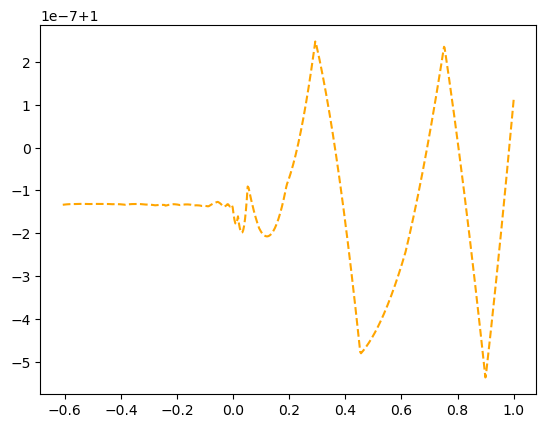

In [239]:
# plt.plot(cos[prob1(cos)>0.1], np.exp(-1/R_avg), label=rf'$\epsilon^2 = {eps2[1]}$, $E_i =${Ei[0]} GeV',color = colors[0])
# plt.plot(cos[prob1(cos)>0.1], np.exp(-1/R_avg_p1), label=rf'$\epsilon^2 = {eps2[1]}$, $E_i =${Ei[0]} GeV',color = colors[0],linestyle='--')
plt.plot(cos[prob1(cos)>0.1], np.exp(-1/R_avg_p1)/np.exp(-1/R_avg[prob1(cos)>0.1]), label=rf'$\epsilon^2 = {eps2[1]}$, $E_i =${Ei[1]} GeV',color = colors[1],linestyle='--')
print(np.mean(np.exp(-1/R_avg)))
print(np.mean(np.exp(-1/R_avg_p1)))



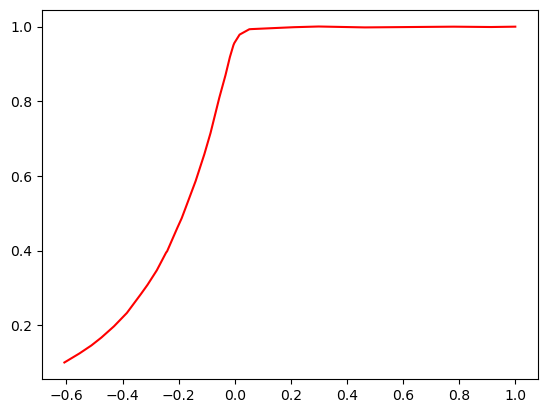

In [240]:
plt.plot(cos[prob1(cos)>0.1],np.exp(-D_overburden(d,theta[prob1(cos)>0.1])/R_avg_p1), label=rf'$\epsilon^2 = {eps2[1]}$, $E_i =${Ei[0]} GeV',color = colors[0])